In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df_water = pd.read_csv("/content/drinking_water_potability.csv")
df_water.shape

(3276, 10)

In [ ]:
df_water.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890456,20791.31898,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.05786,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.54173,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.41744,8.059332,356.886136,363.266516,18.436525,100.341674,4.628771,0
4,9.092223,181.101509,17978.98634,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
df_water.tail()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
3271,4.668102,193.681736,47580.99160,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.80216,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.57822,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.86938,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1
3275,7.874671,195.102299,17404.17706,7.509306,NaN,327.459761,16.140368,78.698446,2.309149,1


In [ ]:
df_water.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [ ]:
df_water.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690300,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833605,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762125,8.114887,359.950170,481.792305,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196010,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [ ]:
df_water.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

<Axes: >

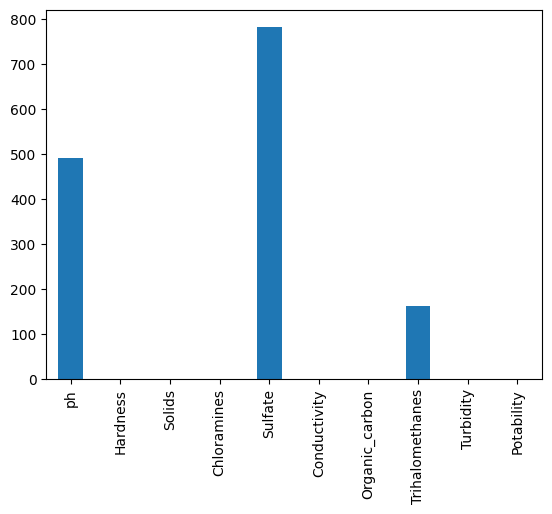

In [ ]:
df_water.isna().sum().plot(kind='bar')

In [ ]:
df_water['ph'] = df_water['ph'].fillna(df_water['ph'].mean())
df_water['ph'].isnull().sum()

sulfate = df_water['Sulfate'].mean()
df_water['Sulfate']= df_water['Sulfate'].fillna(sulfate)

df_water['Trihalomethanes'] = df_water['Trihalomethanes'].fillna(df_water['Trihalomethanes'].median())

In [ ]:
df_water.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

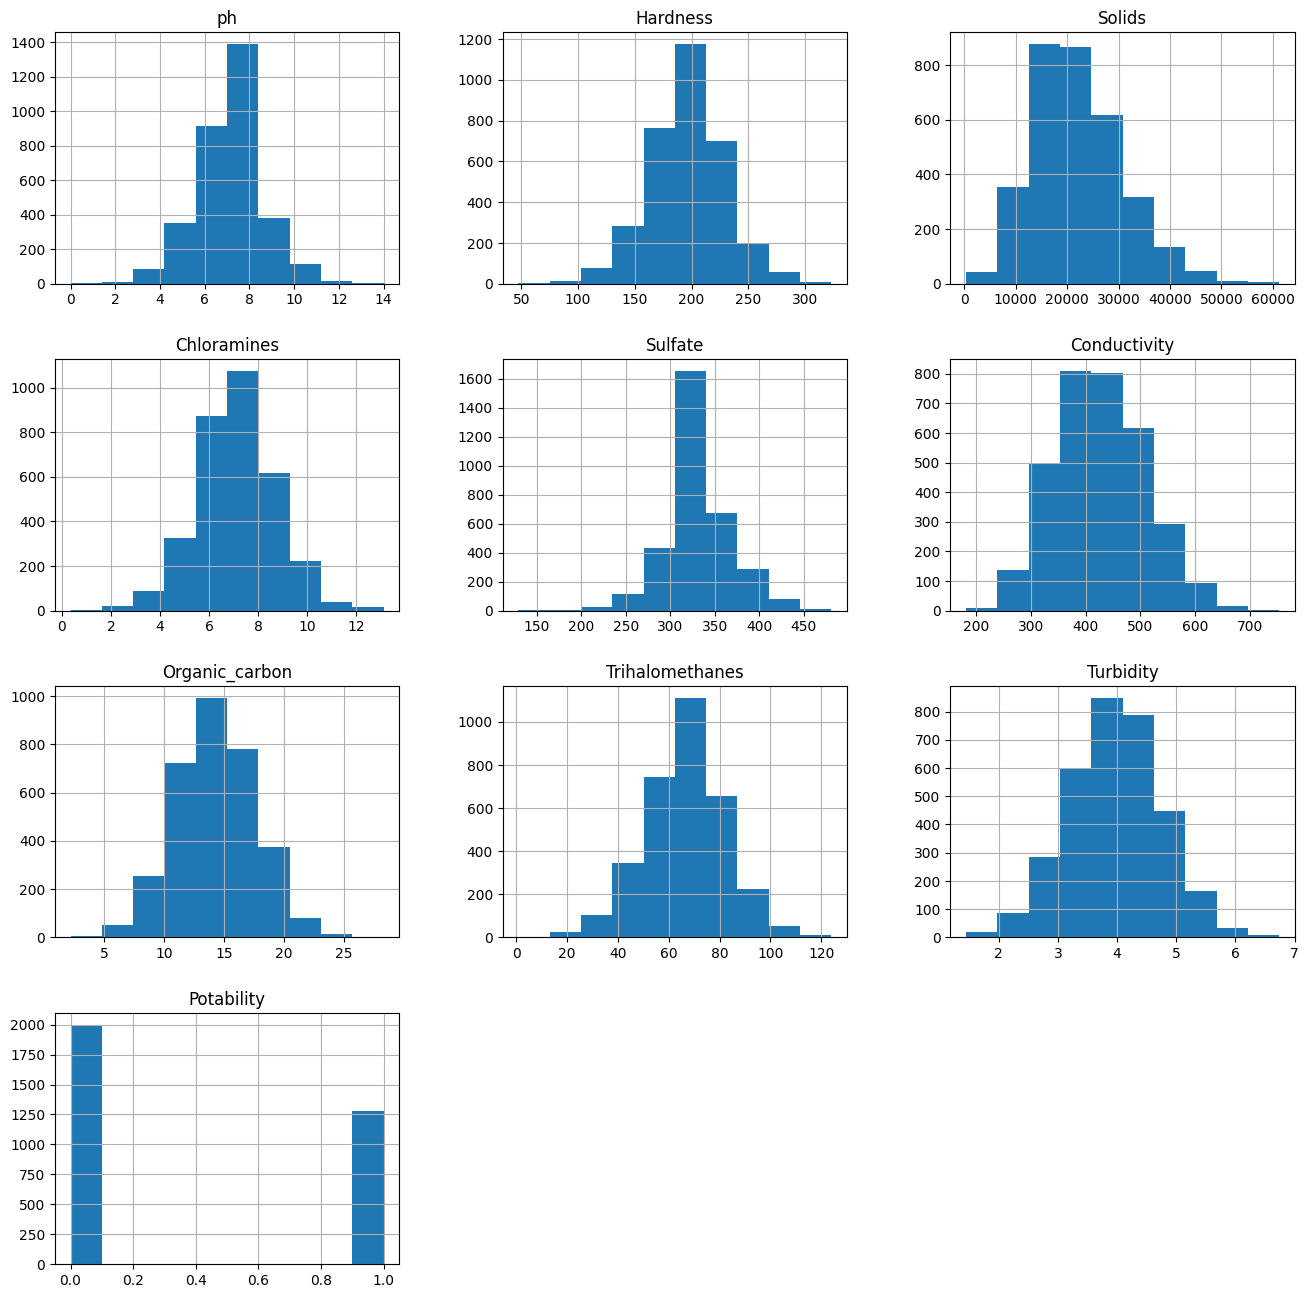

In [ ]:
df_water.hist(figsize=[16,16])
plt.show()

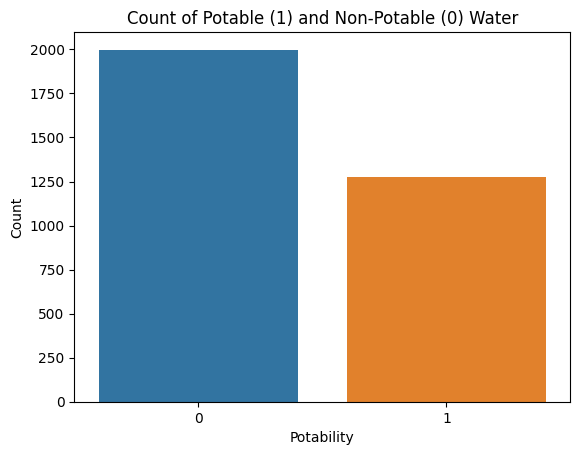

In [ ]:
# Count plot of Potability
sns.countplot(x='Potability', data=df_water)
plt.title('Count of Potable (1) and Non-Potable (0) Water')
plt.xlabel('Potability')
plt.ylabel('Count')
plt.show()

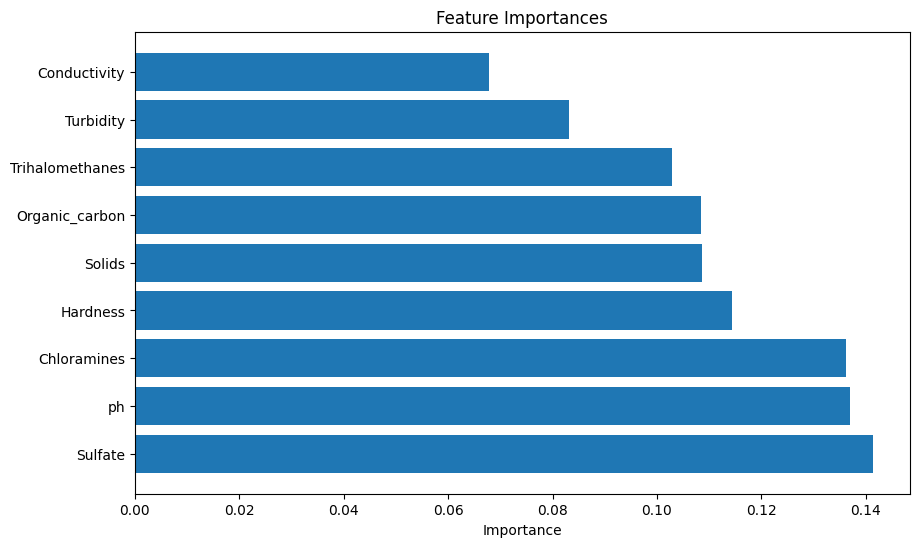

The most significant feature is: Sulfate


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame with the water potability dataset
# and 'Potability' is the target variable indicating water potability (1 for potable, 0 for non-potable)

# Drop any rows with missing values for simplicity
df_water.dropna(inplace=True)

# Separate features and target variable
X = df_water.drop('Potability', axis=1)
y = df_water['Potability']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Decision Tree classifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Get feature importances
feature_importances = clf.feature_importances_

# Create a DataFrame to display feature importances
feature_importance_df_water = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})

# Sort features by importance
feature_importance_df_water = feature_importance_df_water.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df_water['Feature'], feature_importance_df_water['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importances')
plt.show()

# Print the most significant feature
most_significant_feature = feature_importance_df_water.iloc[0]['Feature']
print(f"The most significant feature is: {most_significant_feature}")


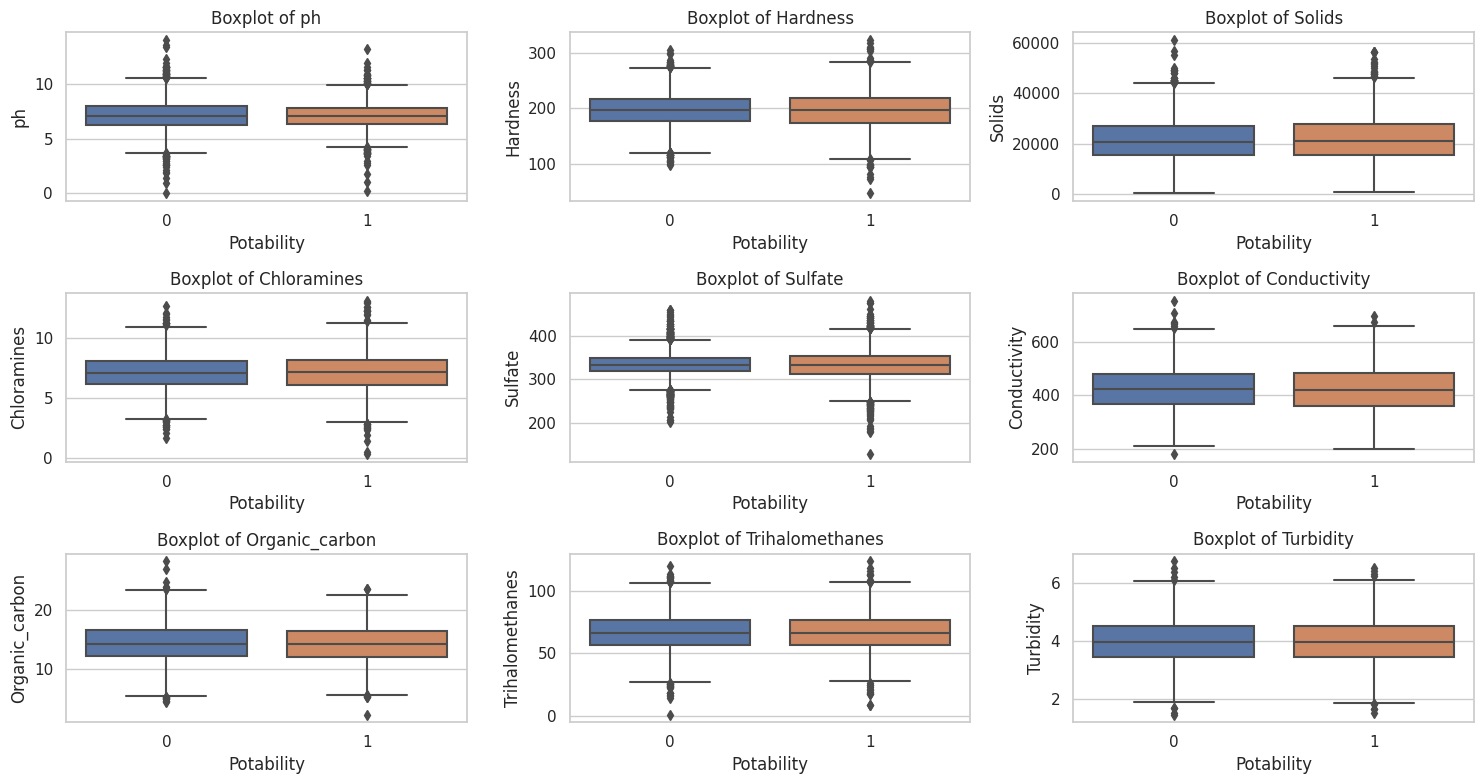

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df_water' is your DataFrame with the water potability dataset

# Drop any rows with missing values for simplicity
df_water.dropna(inplace=True)

# Select relevant features for the box plots
selected_features = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

# Create box plots for each selected feature
plt.figure(figsize=(15, 8))
sns.set(style="whitegrid")  # Set the style of the plots

for feature in selected_features:
    plt.subplot(3, 3, selected_features.index(feature) + 1)
    sns.boxplot(x='Potability', y=feature, data=df_water)
    plt.title(f'Boxplot of {feature}')

plt.tight_layout()
plt.show()


In [ ]:
import statsmodels.api as sm
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.metrics import confusion_matrix


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df_water[[c for c in df_water.columns if c != 'Potability']],df_water['Potability'],train_size = 0.7,random_state = 1)

In [ ]:
sns.pairplot(data=df_water)

In [ ]:
from imblearn.over_sampling import SMOTE

X_train, y_train = SMOTE(random_state=1,n_jobs=-1).fit_resample(X_train,y_train)

In [ ]:
sc = StandardScaler()
X_train[X_train.columns] = sc.fit_transform(X_train)
X_test[X_test.columns] = sc.transform(X_test)

In [ ]:
rf = RandomForestClassifier(random_state=1)
params = {
    "min_samples_split": [10,20,100],
    "max_depth": [5,10,50],
    "min_samples_leaf": [10,20,50],
    "max_leaf_nodes": [10,20,100],
    "max_features": [9,5]
}

rf_grid = GridSearchCV(estimator=rf,param_grid=params,cv=5,scoring='balanced_accuracy',verbose=10,n_jobs = -1).fit(X_train,y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits


In [ ]:
from sklearn.metrics import confusion_matrix
rf = rf_grid.best_estimator_

y_train_pred = rf.predict(X_train)
confusion_matrix(y_train,y_train_pred)

array([[1268,  145],
       [ 143, 1270]])

In [ ]:
y_test_pred = rf.predict(X_test)
cf = confusion_matrix(y_test,y_test_pred)
print(cf)
acc = (cf[0,0] + cf[1,1])/np.sum(cf)
recall = (cf[1,1])/(cf[1,1] + cf[1,0])
spec = (cf[0,0])/(cf[0,1] + cf[0,0])
print(f"Accuracy = {acc} Recall = {recall} Specificity = {spec}")

[[425 160]
 [199 199]]
Accuracy = 0.6347914547304171 Recall = 0.5 Specificity = 0.7264957264957265


In [ ]:
gb = GradientBoostingClassifier(random_state=1)
param_grid = {
    "max_depth": [3,5],
    "min_samples_split": [10,20, 50],
    "min_samples_leaf": [30,50],
    "n_estimators": [50,100],
    "learning_rate": [0.01, 0.05, 0.1]
}

cv = GridSearchCV(estimator=gb, param_grid=param_grid,
                  cv=5,scoring='balanced_accuracy',verbose=10,n_jobs=-1).fit(X_train,y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


In [ ]:
gb = cv.best_estimator_

y_train_pred = gb.predict(X_train)
cf = confusion_matrix(y_train,y_train_pred)

print(cf)
acc = (cf[0,0] + cf[1,1])/np.sum(cf)
recall = (cf[1,1])/(cf[1,1] + cf[1,0])
spec = (cf[0,0])/(cf[0,1] + cf[0,0])
print(f"Accuracy = {acc} Recall = {recall} Specificity = {spec}")

[[1168  245]
 [ 202 1211]]
Accuracy = 0.8418259023354565 Recall = 0.8570417551309271 Specificity = 0.8266100495399858


Text(0.5, 427.9555555555555, 'Predicted label')

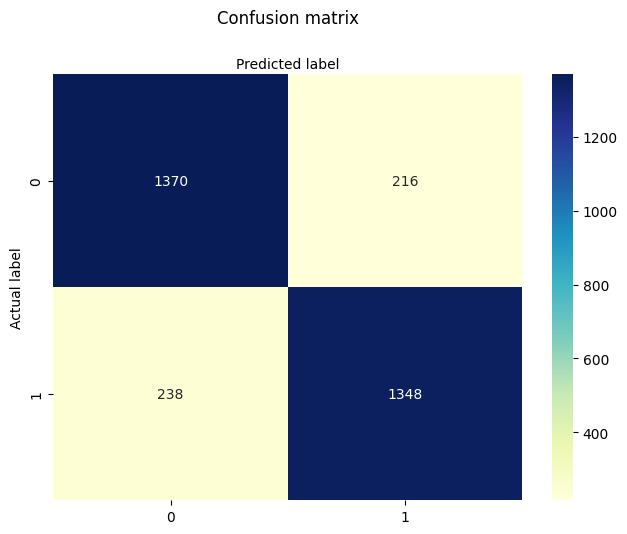

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
class_names=[0,1] # name of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cf), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(random_state=1)

param_grid = {
    "max_depth": [3, 5],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "n_estimators": [50, 100],
    "learning_rate": [0.01, 0.05, 0.1]
}

cv = GridSearchCV(estimator=xgb, param_grid=param_grid,
                  cv=5, scoring='balanced_accuracy', verbose=10, n_jobs=-1).fit(X_train, y_train)


Fitting 5 folds for each of 144 candidates, totalling 720 fits


In [ ]:
gb = cv.best_estimator_

y_train_pred = gb.predict(X_train)
cf = confusion_matrix(y_train,y_train_pred)

print(cf)
acc = (cf[0,0] + cf[1,1])/np.sum(cf)
recall = (cf[1,1])/(cf[1,1] + cf[1,0])
spec = (cf[0,0])/(cf[0,1] + cf[0,0])
print(f"Accuracy = {acc} Recall = {recall} Specificity = {spec}")

[[1272  141]
 [ 113 1300]]
Accuracy = 0.9101203113941967 Recall = 0.9200283085633404 Specificity = 0.9002123142250531


Text(0.5, 427.9555555555555, 'Predicted label')

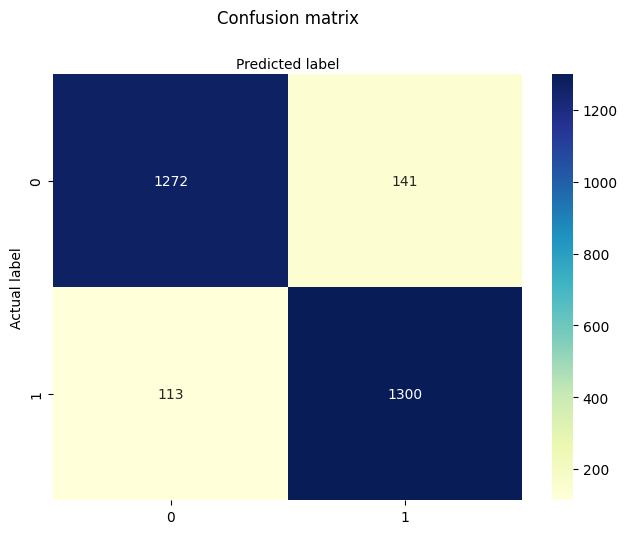

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
class_names=[0,1] # name of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cf), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [ ]:
def Outliers(column):
    q1=column.quantile(0.25)
    q3=column.quantile(0.75)
    IQR=q3-q1
    lower=q1-1.5*(IQR)
    upper=q3+1.5*(IQR)
    return column[(column<lower) | (column>upper)]

In [ ]:
outliers_dict = {}
for column in df_water.select_dtypes(include=['number']):
    outliers = Outliers(df_water[column])
    if not outliers.empty:
        outliers_dict[column] = outliers

# Print potential outliers for each column
for column, outliers in outliers_dict.items():
    print(f"Potential outliers in column '{column}':")
    print(outliers)

Potential outliers in column 'ph':
1        3.716080
9       11.180284
26       3.445062
32      10.433291
36       3.641630
          ...    
3233    10.485604
3246    10.667364
3249    10.808157
3261     3.629922
3269    11.491011
Name: ph, Length: 142, dtype: float64
Potential outliers in column 'Hardness':
18      279.357167
37      304.235912
51      100.457615
67      103.464759
71      116.299330
           ...    
3218    287.975540
3221    303.702627
3230    114.807578
3244    277.065713
3269     94.812545
Name: Hardness, Length: 83, dtype: float64
Potential outliers in column 'Solids':
142     46140.12685
186     45222.50667
283     48621.56395
287     46113.95749
366     52318.91730
378     45249.44903
405     46931.88429
516     45510.58432
546     49074.73041
613     44868.45837
666     52060.22680
987     48002.08460
1031    56867.85924
1068    55334.70280
1077    48410.47101
1096    45141.68604
1186    56351.39630
1302    44896.98411
1332    45166.91214
1343    48204.172

In [ ]:
import pandas as pd
from scipy.stats.mstats import winsorize

# Load your dataset (replace 'your_dataset.csv' with your actual file path)
df = pd.read_csv('/content/drinking_water_potability.csv')

# Specify the columns you want to fix outliers for
columns_to_fix = ['ph', 'Chloramines','Sulfate']

# Winsorize each selected column
for column in columns_to_fix:
    # Set the percentage for winsorizing (e.g., 5% on each end)
    winsorized_values = winsorize(df[column], limits=[0.05, 0.05])

    # Replace the original column with winsorized values
    df[column] = winsorized_values

# Now, df contains the dataset with outliers fixed using winsorizing
# You can save the updated dataset to a new file if needed
df.to_csv('your_updated_dataset.csv', index=False)


In [ ]:
outliers_dict = {}
for column in df.select_dtypes(include=['number']):
    outliers = Outliers(df[column])
    if not outliers.empty:
        outliers_dict[column] = outliers

# Print potential outliers for each column
for column, outliers in outliers_dict.items():
    print(f"Potential outliers in column '{column}':")
    print(outliers)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df[[c for c in df.columns if c != 'Potability']],df['Potability'],train_size = 0.7,random_state = 1)

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(random_state=1)

param_grid = {
    "max_depth": [3, 5],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "n_estimators": [50, 100],
    "learning_rate": [0.01, 0.05, 0.1]
}

cv = GridSearchCV(estimator=xgb, param_grid=param_grid,
                  cv=5, scoring='balanced_accuracy', verbose=10, n_jobs=-1).fit(X_train, y_train)


Fitting 5 folds for each of 144 candidates, totalling 720 fits


In [ ]:
gb = cv.best_estimator_

y_train_pred = gb.predict(X_train)
cf = confusion_matrix(y_train,y_train_pred)

print(cf)
acc = (cf[0,0] + cf[1,1])/np.sum(cf)
recall = (cf[1,1])/(cf[1,1] + cf[1,0])
spec = (cf[0,0])/(cf[0,1] + cf[0,0])
print(f"Accuracy = {acc} Recall = {recall} Specificity = {spec}")

[[1390   23]
 [ 202  678]]
Accuracy = 0.9018752725686873 Recall = 0.7704545454545455 Specificity = 0.9837225760792639
